# Inference using Trained YOLOv11 Model

## RSNA Pneumonia Detection

---

## Objective

In this notebook, we use the trained YOLOv11 model to perform inference on unseen chest X-ray images.

The objectives are:

- Load the trained model
- Predict pneumonia regions
- Display detected bounding boxes
- Show confidence scores
- Save prediction results
- Prepare the model for backend deployment

---

Author

Vansh Nain

B.Tech Artificial Intelligence & Machine Learning

In [2]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.1/46.1 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 24.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 5.1 MB/s eta 0:00:00


In [3]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
from ultralytics import YOLO

import cv2

import os

import matplotlib.pyplot as plt

from PIL import Image

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [5]:
MODEL_PATH = "/content/drive/MyDrive/Major_Project_AI/models/YOLO11_RSNA_v1/weights/best.pt"

model = YOLO(MODEL_PATH)

print("Model Loaded Successfully!")

Model Loaded Successfully!


In [6]:
TEST_DIR = "/content/drive/MyDrive/Major_Project_AI/data/raw/test/images"

print(os.listdir(TEST_DIR)[:10])

['001031d9-f904-4a23-b3e5-2c088acd19c6_png.rf.56456e80a9e6dbf38e38e014adf410c1.jpg', '001916b8-3d30-4935-a5d1-8eaddb1646cd_png.rf.7417ca9bbd570aedc3096aa671f64792.jpg', '01e4fd43-4f2c-421f-bd68-c756dceb5742_png.rf.60ba80aa3d6d5f2c468ba22c76fc5289.jpg', '01f0f4bf-e678-430e-b43d-2968e2c4976c_png.rf.4ff1d710a00bac8f7908b9335ed9df29.jpg', '012a5620-d082-4bb8-9b3b-e72d8938000c_png.rf.d3d02d340d3d234709d62eea3e104f65.jpg', '00704310-78a8-4b38-8475-49f4573b2dbb_png.rf.75e332ac8429b780b1bd16cce955338e.jpg', '01fe92f7-ff87-4f9e-9077-e00e670d1b47_png.rf.e64093154ee50316053ad9408dbcef46.jpg', '00436515-870c-4b36-a041-de91049b9ab4_png.rf.f96d894212d778f167d841ef3b725f3c.jpg', '0087bd3a-55a7-4045-b111-b018fa52d361_png.rf.6d62a551d2de13327a6c688f097c9122.jpg', '00a85be6-6eb0-421d-8acf-ff2dc0007e8a_png.rf.e076f0264c4564a9ee3762e01f02e9c8.jpg']


In [7]:
IMAGE_PATH = os.path.join(TEST_DIR, os.listdir(TEST_DIR)[0])

print(IMAGE_PATH)

/content/drive/MyDrive/Major_Project_AI/data/raw/test/images/001031d9-f904-4a23-b3e5-2c088acd19c6_png.rf.56456e80a9e6dbf38e38e014adf410c1.jpg


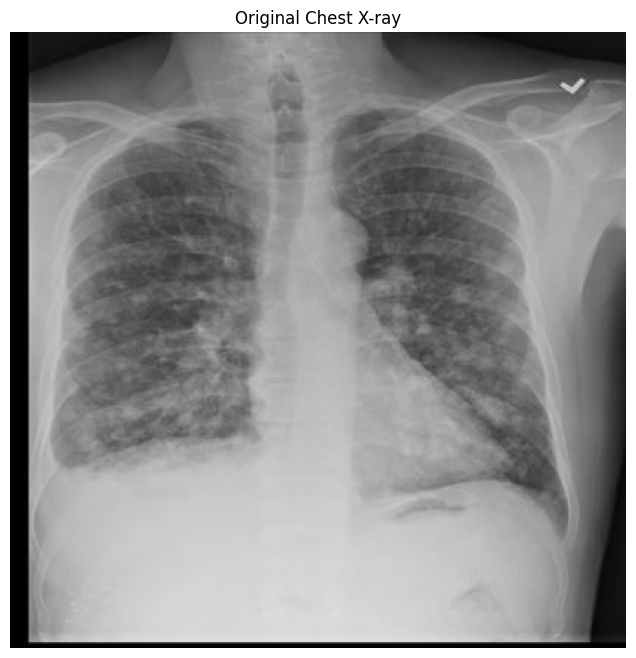

In [8]:
img = Image.open(IMAGE_PATH)

plt.figure(figsize=(8,8))

plt.imshow(img, cmap="gray")

plt.axis("off")

plt.title("Original Chest X-ray")

plt.show()

In [12]:
results = model.predict(
    source=IMAGE_PATH,
    conf=0.01,
    save=True,
    imgsz=640,
    verbose=True
)


image 1/1 /content/drive/MyDrive/Major_Project_AI/data/raw/test/images/001031d9-f904-4a23-b3e5-2c088acd19c6_png.rf.56456e80a9e6dbf38e38e014adf410c1.jpg: 640x640 29 1s, 224.0ms
Speed: 7.4ms preprocess, 224.0ms inference, 27.4ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict


In [13]:
result = results[0]

print(result.boxes)

ultralytics.engine.results.Boxes object with attributes:

cls: tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])
conf: tensor([0.0875, 0.0480, 0.0447, 0.0400, 0.0392, 0.0372, 0.0359, 0.0304, 0.0284, 0.0260, 0.0252, 0.0251, 0.0212, 0.0210, 0.0200, 0.0190, 0.0183, 0.0170, 0.0156, 0.0153, 0.0146, 0.0145, 0.0145, 0.0134, 0.0120, 0.0118, 0.0109, 0.0109, 0.0100])
data: tensor([[9.6183e+01, 4.4811e+01, 2.2974e+02, 2.1323e+02, 8.7485e-02, 1.0000e+00],
        [6.7655e+01, 3.8323e+01, 2.3572e+02, 1.8269e+02, 4.8014e-02, 1.0000e+00],
        [5.0657e+01, 4.6345e+01, 1.2273e+02, 1.9759e+02, 4.4714e-02, 1.0000e+00],
        [5.6234e+01, 2.2612e+01, 2.5488e+02, 2.1573e+02, 4.0033e-02, 1.0000e+00],
        [4.4208e+01, 4.9919e+01, 1.1150e+02, 2.1614e+02, 3.9228e-02, 1.0000e+00],
        [3.9619e+01, 3.2887e+01, 1.0225e+02, 2.0628e+02, 3.7162e-02, 1.0000e+00],
        [6.3398e+01, 7.1773e+01, 1.0315e+02, 1.9765e+02, 3.5874e-02

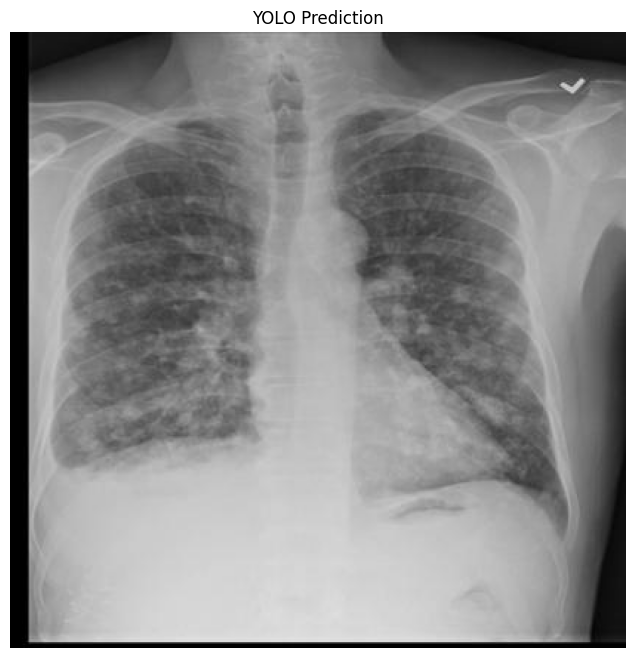

In [11]:
predicted = result.plot()

plt.figure(figsize=(8,8))

plt.imshow(cv2.cvtColor(predicted, cv2.COLOR_BGR2RGB))

plt.axis("off")

plt.title("YOLO Prediction")

plt.show()

In [14]:
from ultralytics import YOLO

MODEL_PATH = "/content/drive/MyDrive/Major_Project_AI/models/YOLO11_RSNA_v1/weights/best.pt"

model = YOLO(MODEL_PATH)

def predict_image(image_path, conf=0.25):
    """
    Run inference on a single chest X-ray.

    Parameters
    ----------
    image_path : str
        Path to the input image.
    conf : float
        Confidence threshold.

    Returns
    -------
    Results
        YOLO prediction result.
    """
    results = model.predict(
        source=image_path,
        conf=conf,
        imgsz=640,
        verbose=False
    )

    return results[0]

In [15]:
OUTPUT_DIR = "/content/drive/MyDrive/Major_Project_AI/predictions"

os.makedirs(OUTPUT_DIR, exist_ok=True)

In [16]:
prediction = predict_image(IMAGE_PATH, conf=0.25)

annotated = prediction.plot()

output_path = os.path.join(
    OUTPUT_DIR,
    "prediction_result.jpg"
)

cv2.imwrite(output_path, annotated)

print("Saved:", output_path)

Saved: /content/drive/MyDrive/Major_Project_AI/predictions/prediction_result.jpg
